In [9]:
import pandas as pd
import matplotlib.pyplot as pt
import pyterrier as pt
from ir_measures import *
if not pt.started():
    pt.init()

/tmp/ipykernel_7985/1354918087.py:5: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


In [6]:
docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

In [17]:
run_names = [
    "SPLADE (OHSUMED 8 Negs)",
    "SPLADE (OHSUMED 8 Negs) >> T5 Filter",
    "SPLADE SANS Strategy 1",
    "Learned Vocabulary (Add) (OHSUMED 8 Negs)"
]

run_files = [
    pt.io.read_results("/nfs/primary/SPLADE/splade_class/runs/splade_ohsumed_multiple_negative"),
    pt.io.read_results("/nfs/primary/SPLADE/splade_class/runs/splade_ohsumed_multiple_negative_t5_filter"),
    pt.io.read_results("/nfs/primary/SPLADE/splade_sans/runs/splade_max_strategy1_group8"),
    pt.io.read_results("/nfs/primary/SPLADE/splade_class/runs/splade_ohsumed_8_negs_add.run")
]

def _sens_docs(qrels, run):
    if "sensitivity" in run.columns:
        run = run.drop(columns = ["sensitivity"])
    merged = pd.merge(run, docs, left_on = "doc_id", right_on = "docno")
    return merged.sensitivity.sum()
    
import ir_measures
sens_docs = ir_measures.define_byquery(
    _sens_docs, 
    name="sens_docs")

results = pt.Experiment(
    run_files,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = run_names,
    perquery = True
)

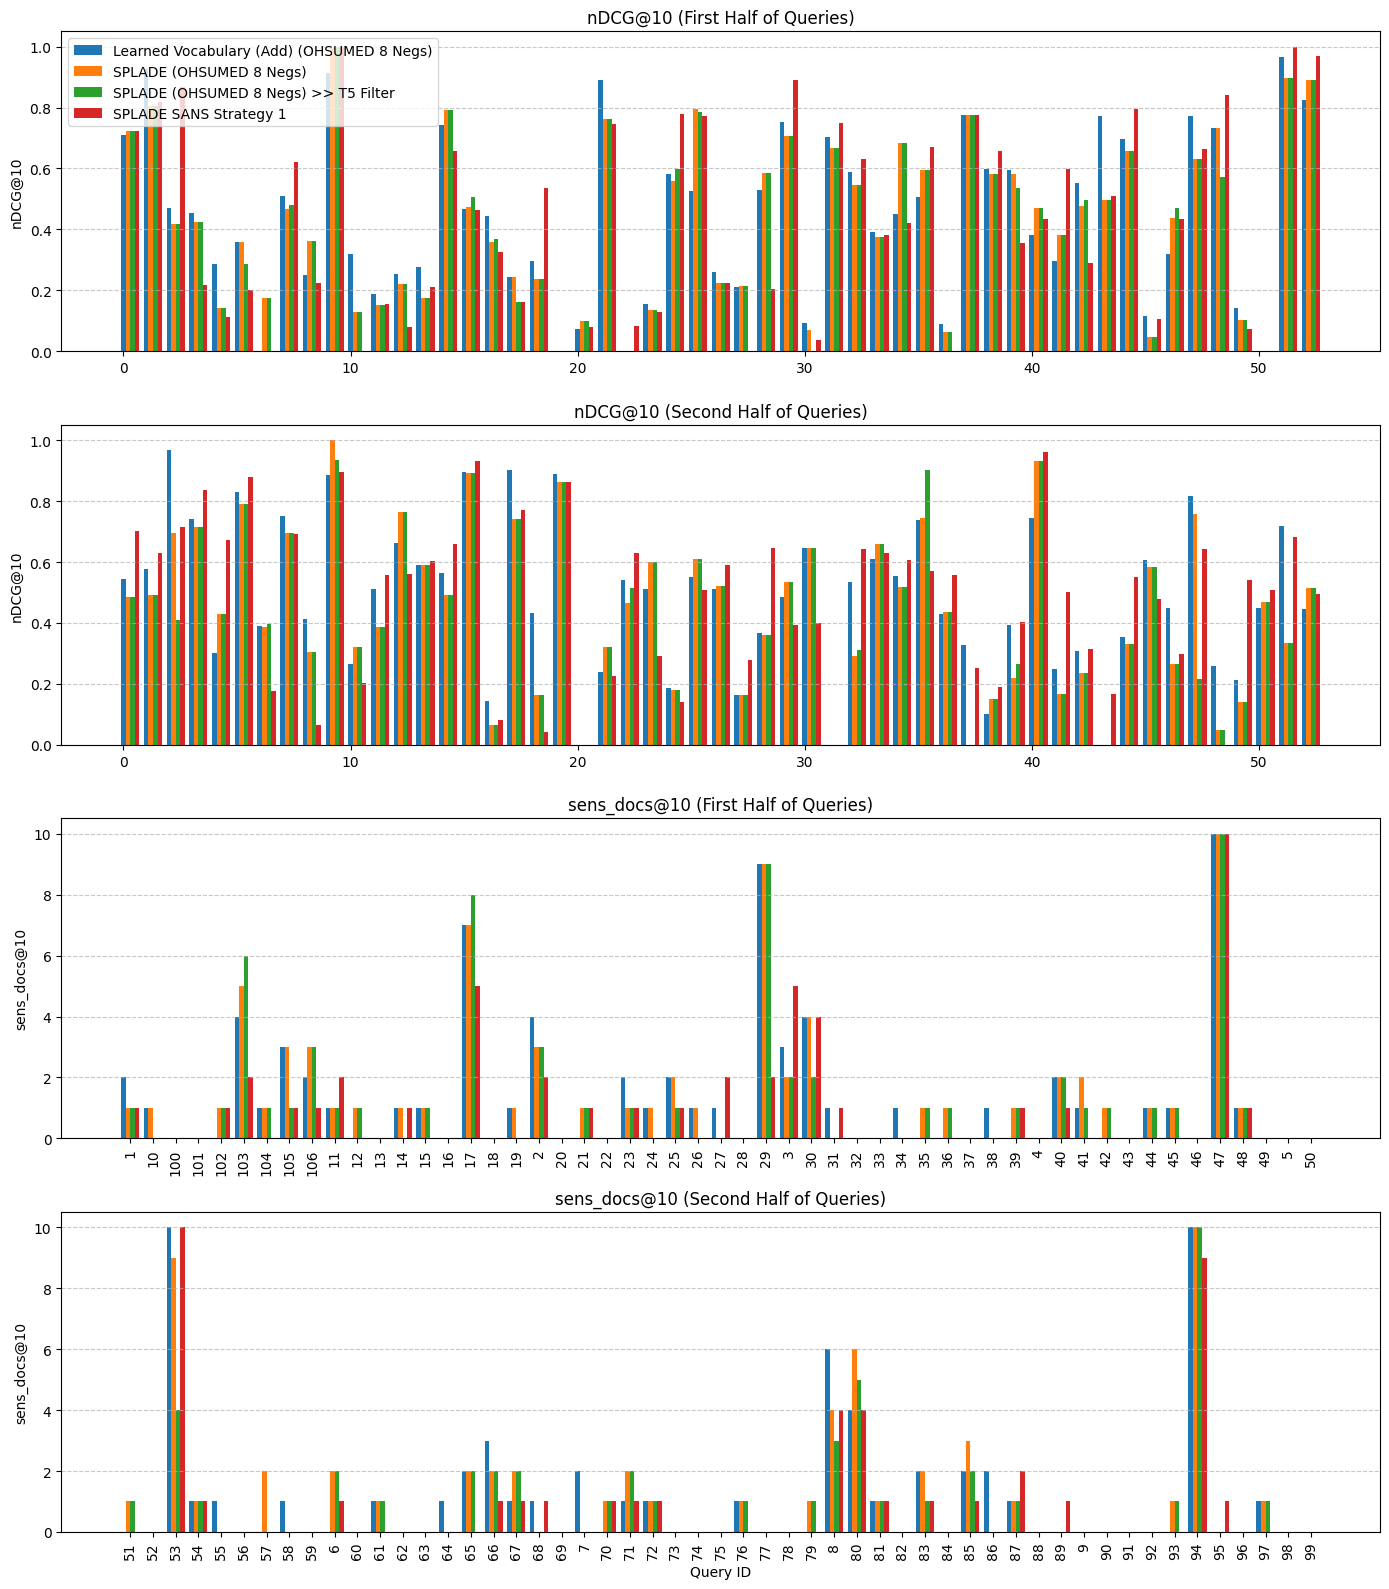

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your dataframe
# results = pd.read_csv("your_file.csv")  # Uncomment if loading from a file

# Get unique systems and queries
systems = results["name"].unique()
queries = sorted(results["qid"].unique())

# Split queries into two halves
mid = len(queries) // 2
queries_1 = queries[:mid]  # First half
queries_2 = queries[mid:]  # Second half

# Separate data for each measure
ndcg_df = results[results["measure"] == "nDCG@10"]
sens_df = results[results["measure"] == "sens_docs@10"]

# Define bar width
bar_width = 0.2
x1 = np.arange(len(queries_1))  # X positions for first half
x2 = np.arange(len(queries_2))  # X positions for second half

# Create 4 stacked subplots
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

# Plot nDCG@10 for first half
for i, system in enumerate(systems):
    system_data = ndcg_df[ndcg_df["name"] == system].set_index("qid")["value"]
    axes[0].bar(x1 + i * bar_width, system_data.reindex(queries_1), width=bar_width, label=system)

axes[0].set_ylabel("nDCG@10")
axes[0].set_title("nDCG@10 (First Half of Queries)")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Plot nDCG@10 for second half
for i, system in enumerate(systems):
    system_data = ndcg_df[ndcg_df["name"] == system].set_index("qid")["value"]
    axes[1].bar(x2 + i * bar_width, system_data.reindex(queries_2), width=bar_width, label=system)

axes[1].set_ylabel("nDCG@10")
axes[1].set_title("nDCG@10 (Second Half of Queries)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Plot sens_docs@10 for first half
for i, system in enumerate(systems):
    system_data = sens_df[sens_df["name"] == system].set_index("qid")["value"]
    axes[2].bar(x1 + i * bar_width, system_data.reindex(queries_1), width=bar_width, label=system)

axes[2].set_ylabel("sens_docs@10")
axes[2].set_title("sens_docs@10 (First Half of Queries)")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Plot sens_docs@10 for second half
for i, system in enumerate(systems):
    system_data = sens_df[sens_df["name"] == system].set_index("qid")["value"]
    axes[3].bar(x2 + i * bar_width, system_data.reindex(queries_2), width=bar_width, label=system)

axes[3].set_ylabel("sens_docs@10")
axes[3].set_title("sens_docs@10 (Second Half of Queries)")
axes[3].set_xlabel("Query ID")
axes[3].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust x-ticks (only on bottom subplots)
axes[2].set_xticks(x1 + (bar_width * (len(systems) - 1) / 2))
axes[2].set_xticklabels(queries_1, rotation=90)
axes[3].set_xticks(x2 + (bar_width * (len(systems) - 1) / 2))
axes[3].set_xticklabels(queries_2, rotation=90)

plt.tight_layout()
plt.show()


/tmp/ipykernel_7985/4019926031.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = plt.cm.get_cmap("viridis", len(systems))


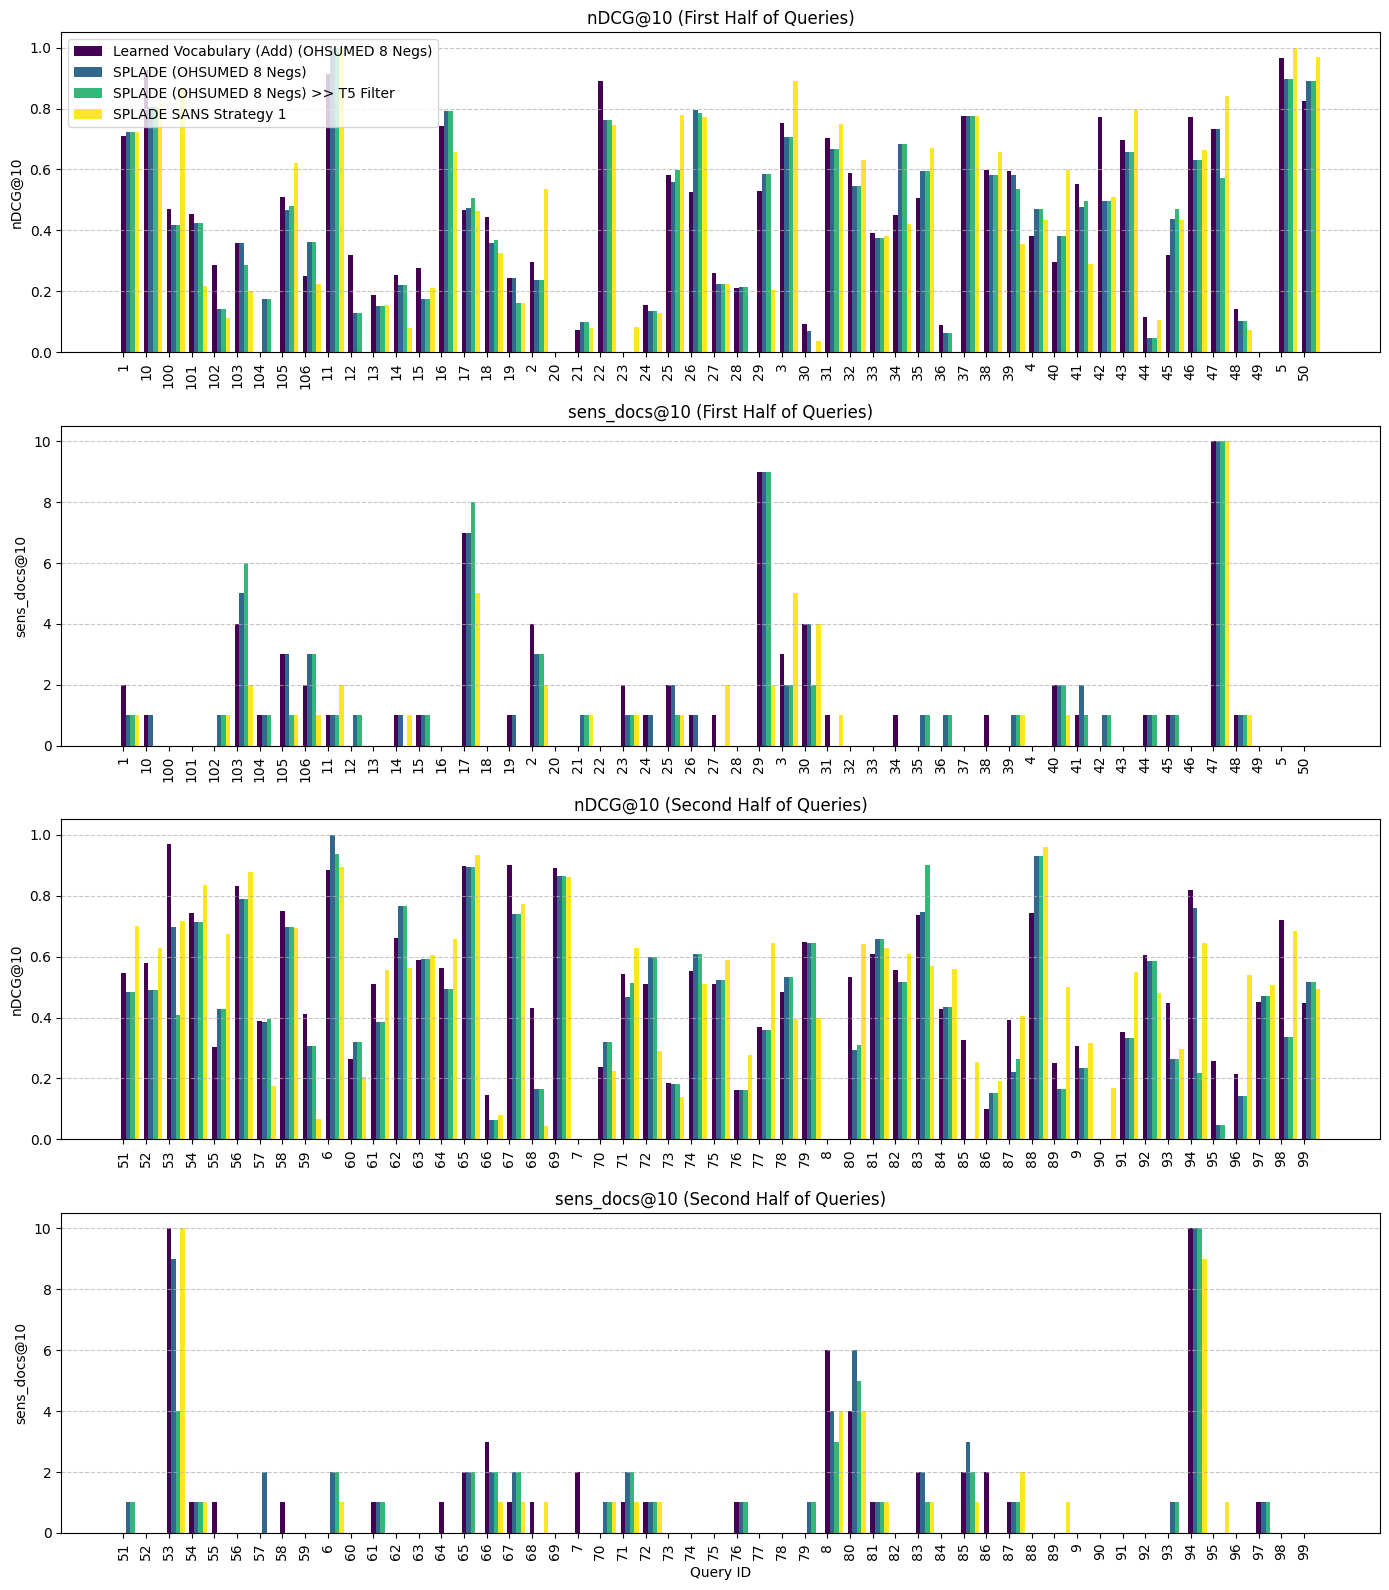

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

color_palette = plt.cm.get_cmap("viridis", len(systems))

# Get unique systems and queries
systems = results["name"].unique()
queries = sorted(results["qid"].unique())

# Split queries into two halves
mid = len(queries) // 2
queries_1 = queries[:mid]  # First half
queries_2 = queries[mid:]  # Second half

# Separate data for each measure
ndcg_df = results[results["measure"] == "nDCG@10"]
sens_df = results[results["measure"] == "sens_docs@10"]

# Define bar width
bar_width = 0.2
x1 = np.arange(len(queries_1))  # X positions for first half
x2 = np.arange(len(queries_2))  # X positions for second half

# Create 4 stacked subplots (now alternating nDCG and sens_docs)
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

# Plot nDCG@10 for first half
for i, system in enumerate(systems):
    system_data = ndcg_df[ndcg_df["name"] == system].set_index("qid")["value"]
    axes[0].bar(x1 + i * bar_width, system_data.reindex(queries_1), width=bar_width, label=system, color=color_palette(i))

axes[0].set_ylabel("nDCG@10")
axes[0].set_title("nDCG@10 (First Half of Queries)")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Plot sens_docs@10 for first half
for i, system in enumerate(systems):
    system_data = sens_df[sens_df["name"] == system].set_index("qid")["value"]
    axes[1].bar(x1 + i * bar_width, system_data.reindex(queries_1), width=bar_width, label=system, color=color_palette(i))

axes[1].set_ylabel("sens_docs@10")
axes[1].set_title("sens_docs@10 (First Half of Queries)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Plot nDCG@10 for second half
for i, system in enumerate(systems):
    system_data = ndcg_df[ndcg_df["name"] == system].set_index("qid")["value"]
    axes[2].bar(x2 + i * bar_width, system_data.reindex(queries_2), width=bar_width, label=system, color=color_palette(i))

axes[2].set_ylabel("nDCG@10")
axes[2].set_title("nDCG@10 (Second Half of Queries)")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)

# Plot sens_docs@10 for second half
for i, system in enumerate(systems):
    system_data = sens_df[sens_df["name"] == system].set_index("qid")["value"]
    axes[3].bar(x2 + i * bar_width, system_data.reindex(queries_2), width=bar_width, label=system, color=color_palette(i))

axes[3].set_ylabel("sens_docs@10")
axes[3].set_title("sens_docs@10 (Second Half of Queries)")
axes[3].set_xlabel("Query ID")
axes[3].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust x-ticks (show all qids)
axes[0].set_xticks(x1)
axes[0].set_xticklabels(queries_1, rotation=90)

axes[1].set_xticks(x1)
axes[1].set_xticklabels(queries_1, rotation=90)

axes[2].set_xticks(x2)
axes[2].set_xticklabels(queries_2, rotation=90)

axes[3].set_xticks(x2)
axes[3].set_xticklabels(queries_2, rotation=90)

plt.tight_layout()
plt.savefig("./plots/selected_approaches_per_query_analysis_cb.png", dpi = 1080)
plt.show()